<a href="https://colab.research.google.com/github/Cristiand056/practicas_IA/blob/main/weatherAUS_rainfall_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sandhyapalaniappan/rainfall-prediction-dataset-cleaned-weatheraus")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/rainfall-prediction-dataset-cleaned-weatheraus


In [ ]:
import os
os.listdir(path)

['weatherAUS_rainfall_prediction_dataset_cleaned.csv']

In [ ]:
file_path = os.path.join(path, 'weatherAUS_rainfall_prediction_dataset_cleaned.csv')

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = pd.read_csv(file_path)

In [ ]:
data.sample(10)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
9195,2012-10-02,Albury,4.6,22.2,0.0,5.47,7.61,SSW,19.0,E,...,66.0,44.0,1033.0,1028.6,4.45,4.51,13.7,21.1,No,No
138725,2017-03-24,Witchcliffe,15.1,20.8,3.4,5.47,7.61,SSE,33.0,SSE,...,100.0,70.0,1017.3,1016.0,4.45,4.51,17.0,19.8,Yes,No
104695,2011-06-01,Sale,3.3,15.4,0.2,1.00,5.60,E,17.0,WNW,...,99.0,73.0,1027.7,1026.1,6.00,1.00,5.5,15.1,No,No
49952,2015-06-02,Katherine,21.1,32.6,0.0,6.40,7.61,SE,37.0,SE,...,54.0,34.0,1017.2,1012.3,1.00,0.00,24.1,32.5,No,No
119022,2015-01-01,Townsville,27.6,32.6,0.0,8.00,2.20,ENE,35.0,ENE,...,63.0,71.0,1010.3,1008.3,7.00,7.00,31.3,29.7,No,Yes
141391,2013-12-20,Wollongong,20.4,27.1,0.0,5.47,7.61,NNE,35.0,NNE,...,82.0,69.0,1015.0,1010.9,4.45,4.51,22.9,25.2,No,No
106080,2017-01-12,Sale,11.6,26.0,0.0,5.47,7.61,E,35.0,W,...,66.0,42.0,1013.6,1010.9,4.45,4.51,17.6,25.0,No,No
29048,2016-06-07,Canberra,7.1,11.3,0.0,5.47,7.61,NW,43.0,NW,...,76.0,76.0,1004.2,1004.1,8.00,8.00,9.3,9.6,No,No
59745,2015-06-15,MelbourneAirport,5.5,17.1,0.0,0.60,3.10,NNE,31.0,N,...,96.0,54.0,1026.4,1022.9,7.00,7.00,8.1,16.4,No,Yes
39354,2009-03-06,Dartmoor,8.2,17.6,0.8,3.00,0.00,W,26.0,N,...,86.0,68.0,1018.2,1016.7,4.45,4.51,12.7,16.7,No,No


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        145460 non-null  float64
 3   MaxTemp        145460 non-null  float64
 4   Rainfall       145460 non-null  float64
 5   Evaporation    145460 non-null  float64
 6   Sunshine       145460 non-null  float64
 7   WindGustDir    145460 non-null  object 
 8   WindGustSpeed  145460 non-null  float64
 9   WindDir9am     145460 non-null  object 
 10  WindDir3pm     145460 non-null  object 
 11  WindSpeed9am   145460 non-null  float64
 12  WindSpeed3pm   145460 non-null  float64
 13  Humidity9am    145460 non-null  float64
 14  Humidity3pm    145460 non-null  float64
 15  Pressure9am    145460 non-null  float64
 16  Pressure3pm    145460 non-null  float64
 17  Cloud9am       145460 non-nul

In [ ]:
data.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000
mean,12.193993,23.221337,2.360898,5.468995,7.610612,40.035567,14.043384,18.662601,68.880816,51.539143,1017.649946,1015.256314,4.448437,4.509959,16.990624,21.683306
std,6.365750,7.088124,8.382488,3.161541,2.729486,13.118253,8.861059,8.716581,18.854765,20.471189,6.728467,6.663973,2.265605,2.092954,6.449221,6.850057
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000
25%,7.700000,18.000000,0.000000,4.000000,7.610000,31.000000,7.000000,13.000000,57.000000,37.000000,1013.500000,1011.100000,3.000000,4.000000,12.300000,16.700000
50%,12.100000,22.700000,0.000000,5.470000,7.610000,39.000000,13.000000,18.660000,69.000000,51.540000,1017.650000,1015.260000,4.450000,4.510000,16.800000,21.400000
75%,16.800000,28.200000,1.000000,5.470000,8.700000,46.000000,19.000000,24.000000,83.000000,65.000000,1021.800000,1019.400000,6.000000,6.000000,21.500000,26.200000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000


In [ ]:
data["Date"] = pd.to_datetime(data["Date"])

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
px.scatter(data, x='MinTemp', y='MaxTemp', color='RainTomorrow')

<Axes: xlabel='RainTomorrow', ylabel='count'>

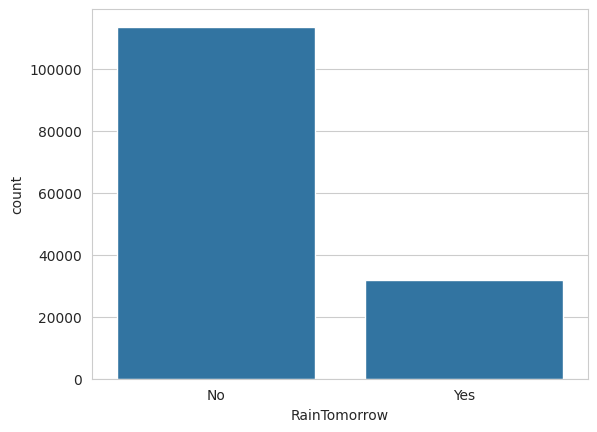

In [114]:
sns.countplot(data=data, x='RainTomorrow')

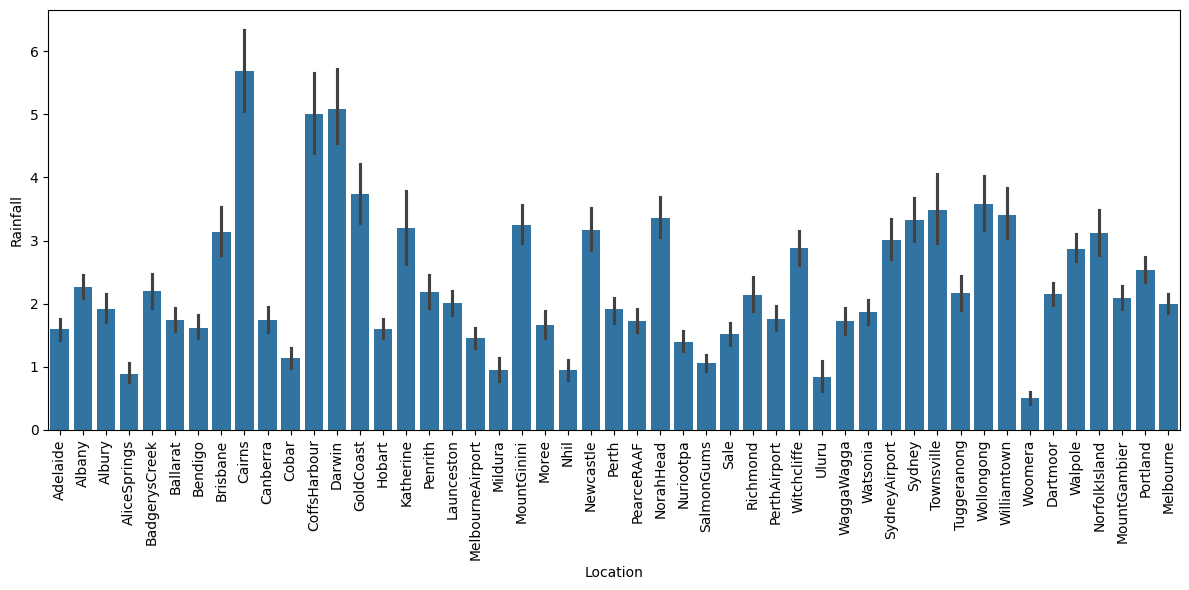

In [ ]:
order = data.groupby('Location')["Rainfall"].median().sort_values().index
plt.figure(figsize=(12, 6))
sns.barplot(x='Location', y='Rainfall', data=data, order=order)
sns.set_style('whitegrid')
plt.xticks(rotation=90)
plt.tight_layout()

In [ ]:
data["Date"] = pd.to_datetime(data["Date"])

data_2017_2014 = data[data["Date"].dt.year > 2013]

data_2017_2014_monthly = data_2017_2014.groupby(pd.Grouper(key="Date", freq="M"))["Rainfall"].mean().reset_index()


fig = px.line(data_2017_2014_monthly,x="Date",y="Rainfall",title="Caidad promedio de lluvias por mes, en los ultimos años")
fig.show()

#Limpiando el dataset, para entrenar el modelo

In [ ]:
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["Day"] = data["Date"].dt.day

In [ ]:
data = data.drop("Date", axis=1)

In [ ]:
data.sample(10)

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day
15225,BadgerysCreek,15.6,20.3,20.4,5.47,7.61,SW,24.0,WSW,NNE,...,1004.9,4.45,4.51,17.0,19.6,Yes,Yes,2012,2,3
115878,SydneyAirport,19.9,25.4,0.0,6.80,0.30,S,44.0,NW,NW,...,1016.1,7.00,7.00,21.5,24.1,No,No,2016,3,25
144823,Woomera,7.1,26.3,0.0,8.00,9.80,NNE,43.0,NNE,NNW,...,1013.9,0.00,0.00,18.0,24.9,No,No,2012,9,25
59351,MelbourneAirport,4.6,16.2,0.0,4.20,1.20,N,67.0,NNE,N,...,1007.7,7.00,7.00,10.4,15.2,No,No,2009,9,6
103081,Richmond,16.6,22.1,2.8,33.80,7.61,SE,26.0,SSW,SE,...,1011.8,4.45,4.51,19.2,21.5,Yes,No,2011,1,4
96465,PerthAirport,21.0,27.1,0.0,8.00,10.60,SW,46.0,SW,WSW,...,1009.5,5.00,1.00,23.5,25.8,No,No,2015,2,27
106390,Sale,7.1,19.3,0.0,5.47,7.61,NW,61.0,NW,NW,...,1011.8,4.45,4.51,14.4,18.6,No,No,2015,6,8
20162,Bendigo,6.5,21.2,0.0,5.47,7.61,S,50.0,S,SSE,...,1017.2,4.45,3.00,14.9,20.3,No,No,2015,10,22
42333,Darwin,13.7,26.6,0.0,5.00,10.90,SE,39.0,ESE,SE,...,1014.9,3.00,4.00,18.6,25.5,No,No,2011,6,16
42095,Darwin,18.5,31.7,0.0,5.00,9.70,ENE,37.0,ENE,SE,...,1013.9,0.00,1.00,24.1,31.5,No,No,2015,7,21


In [ ]:
X = data.drop("RainTomorrow", axis=1)
y = data["RainTomorrow"]

In [ ]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import make_column_transformer

In [53]:
variables_categoricas = ["Location", "WindGustDir", "WindDir9am", "WindDir3pm", "RainToday"]

one_hot = make_column_transformer(
    (OneHotEncoder(drop="if_binary", handle_unknown="ignore"), variables_categoricas),
    remainder="passthrough",
    sparse_threshold=0
)

In [54]:
X_encoded = one_hot.fit_transform(X)

In [ ]:
X_encoded

array([[1.000e+00, 0.000e+00, 0.000e+00, ..., 2.010e+03, 4.000e+00,
        3.000e+01],
       [1.000e+00, 0.000e+00, 0.000e+00, ..., 2.014e+03, 7.000e+00,
        2.200e+01],
       [1.000e+00, 0.000e+00, 0.000e+00, ..., 2.014e+03, 7.000e+00,
        2.300e+01],
       ...,
       [0.000e+00, 0.000e+00, 0.000e+00, ..., 2.012e+03, 1.000e+00,
        1.600e+01],
       [0.000e+00, 0.000e+00, 0.000e+00, ..., 2.012e+03, 1.000e+00,
        1.800e+01],
       [0.000e+00, 0.000e+00, 0.000e+00, ..., 2.017e+03, 1.000e+00,
        1.000e+01]])

In [ ]:
feature_names = one_hot.get_feature_names_out()

X_transformed = pd.DataFrame(X_encoded, columns=feature_names)

X_transformed.index = X.index

X_transformed.sample(10)

,onehotencoder__Location_Adelaide,onehotencoder__Location_Albany,onehotencoder__Location_Albury,onehotencoder__Location_AliceSprings,onehotencoder__Location_BadgerysCreek,onehotencoder__Location_Ballarat,onehotencoder__Location_Bendigo,onehotencoder__Location_Brisbane,onehotencoder__Location_Cairns,onehotencoder__Location_Canberra,...,remainder__Humidity3pm,remainder__Pressure9am,remainder__Pressure3pm,remainder__Cloud9am,remainder__Cloud3pm,remainder__Temp9am,remainder__Temp3pm,remainder__Year,remainder__Month,remainder__Day
78200,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,67.00,1021.00,1016.40,4.45,4.51,22.4,24.70,2010.0,4.0,23.0
131735,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,40.00,1021.30,1020.00,7.00,6.00,15.1,19.20,2016.0,3.0,27.0
2688,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,35.00,1024.80,1021.20,4.45,4.51,16.4,21.30,2012.0,11.0,13.0
126960,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,35.00,1027.00,1023.40,0.00,3.00,5.9,17.00,2012.0,5.0,15.0
4241,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,51.54,1018.40,1017.60,6.00,4.51,17.2,21.68,2017.0,1.0,17.0
111878,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,88.00,1017.90,1020.10,6.00,7.00,13.1,13.60,2009.0,6.0,16.0
89617,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,44.00,1017.65,1015.26,4.45,4.51,19.1,26.70,2013.0,4.0,1.0
45974,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,67.00,1019.60,1016.10,4.45,4.51,22.1,25.00,2010.0,4.0,24.0
86768,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,55.00,1023.00,1021.40,5.00,4.00,14.9,19.10,2012.0,8.0,29.0
35781,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,78.00,1023.60,1020.80,8.00,7.00,16.2,19.20,2009.0,6.0,21.0


In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=200)

In [ ]:
model_arbol = Pipeline(steps=[
    ("preprocessor", one_hot),
    ("classifier", RandomForestClassifier(random_state=200, class_weight="balanced"))
])

model_arbol.fit(X_train, y_train)
y_pred = model_arbol.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("R2 Score:", roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8547710710848343
R2 Score: 0.7172556677868352
              precision    recall  f1-score   support

           0       0.87      0.96      0.91     22713
           1       0.78      0.47      0.59      6379

    accuracy                           0.85     29092
   macro avg       0.82      0.72      0.75     29092
weighted avg       0.85      0.85      0.84     29092



In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

modelo_arbol = ImbPipeline(steps=[
    ("preprocessor", one_hot),
    ("smote", SMOTE(random_state=200)),
    ("classifier", RandomForestClassifier(random_state=200, class_weight="balanced", n_estimators=400, max_depth=5))
])

model_arbol.fit(X_train, y_train)
y_pred = model_arbol.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("R2 Score:", roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8547710710848343
R2 Score: 0.7172556677868352
              precision    recall  f1-score   support

           0       0.87      0.96      0.91     22713
           1       0.78      0.47      0.59      6379

    accuracy                           0.85     29092
   macro avg       0.82      0.72      0.75     29092
weighted avg       0.85      0.85      0.84     29092



In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

modelo_xgboost = ImbPipeline(steps=[
    ("onehot", one_hot),
    ("smote", SMOTE(random_state=42)),
    ("xgb", xgb)
])

modelo_xgboost.fit(X_train, y_train)

y_pred = modelo_xgboost.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.8591365323800357
              precision    recall  f1-score   support

          No       0.88      0.95      0.91     22713
         Yes       0.74      0.55      0.63      6379

    accuracy                           0.86     29092
   macro avg       0.81      0.75      0.77     29092
weighted avg       0.85      0.86      0.85     29092



In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [34]:
param_dist = {
    "xgb__n_estimators": [200, 300, 400],
    "xgb__max_depth": [3, 5, 7, 9],
    "xgb__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "xgb__subsample": [0.6, 0.8, 1.0],
    "xgb__colsample_bytree": [0.6, 0.8, 1.0],
    "xgb__gamma": [0, 1, 5],
    "xgb__scale_pos_weight": [1, (len(y_train) - sum(y_train)) / sum(y_train)]
}


search = RandomizedSearchCV(
    modelo_xgboost,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Mejores parámetros:", search.best_params_)
print("Mejor score:", search.best_score_)

# Evaluar en test
best_model = search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

Fitting 3 folds for each of 20 candidates, totalling 60 fits


KeyboardInterrupt: 

In [43]:
!pip install scikeras

#Intento pipeline con keras

In [67]:
from tensorflow import keras
from keras import layers

#por temas de versiones esta desactualizada en colab por el momento
from scikeras.wrappers import KerasClassifier
#

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [103]:
variables_numericas = X_transformed.select_dtypes(include=['float64', 'int64']).columns.tolist()
print(variables_numericas)

['onehotencoder__Location_Adelaide', 'onehotencoder__Location_Albany', 'onehotencoder__Location_Albury', 'onehotencoder__Location_AliceSprings', 'onehotencoder__Location_BadgerysCreek', 'onehotencoder__Location_Ballarat', 'onehotencoder__Location_Bendigo', 'onehotencoder__Location_Brisbane', 'onehotencoder__Location_Cairns', 'onehotencoder__Location_Canberra', 'onehotencoder__Location_Cobar', 'onehotencoder__Location_CoffsHarbour', 'onehotencoder__Location_Dartmoor', 'onehotencoder__Location_Darwin', 'onehotencoder__Location_GoldCoast', 'onehotencoder__Location_Hobart', 'onehotencoder__Location_Katherine', 'onehotencoder__Location_Launceston', 'onehotencoder__Location_Melbourne', 'onehotencoder__Location_MelbourneAirport', 'onehotencoder__Location_Mildura', 'onehotencoder__Location_Moree', 'onehotencoder__Location_MountGambier', 'onehotencoder__Location_MountGinini', 'onehotencoder__Location_Newcastle', 'onehotencoder__Location_Nhil', 'onehotencoder__Location_NorahHead', 'onehotencoder

In [101]:
X_transformed.sample(10)

,onehotencoder__Location_Adelaide,onehotencoder__Location_Albany,onehotencoder__Location_Albury,onehotencoder__Location_AliceSprings,onehotencoder__Location_BadgerysCreek,onehotencoder__Location_Ballarat,onehotencoder__Location_Bendigo,onehotencoder__Location_Brisbane,onehotencoder__Location_Cairns,onehotencoder__Location_Canberra,...,remainder__Humidity3pm,remainder__Pressure9am,remainder__Pressure3pm,remainder__Cloud9am,remainder__Cloud3pm,remainder__Temp9am,remainder__Temp3pm,remainder__Year,remainder__Month,remainder__Day
92100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,59.00,1017.65,1015.26,4.45,4.51,11.80,18.00,2017.0,6.0,22.0
142056,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,78.00,1010.60,1012.10,7.00,8.00,20.60,20.90,2017.0,1.0,2.0
62964,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.00,1015.70,1012.70,0.00,3.00,26.10,39.30,2016.0,1.0,10.0
37934,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,68.00,1018.80,1020.50,4.45,4.51,11.00,13.60,2016.0,10.0,12.0
55740,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,51.54,1017.65,1015.26,4.45,4.51,16.99,21.68,2015.0,3.0,1.0
133675,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,64.00,1026.40,1024.20,2.00,4.00,22.70,25.60,2014.0,3.0,20.0
80409,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,71.00,1016.00,1015.30,5.00,7.00,23.40,22.20,2015.0,2.0,16.0
61617,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,77.00,1010.80,1012.20,5.00,5.00,10.20,14.90,2014.0,6.0,24.0
61994,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,60.00,1017.20,1015.30,7.00,3.00,14.30,19.90,2013.0,7.0,14.0
101164,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,64.00,1006.80,1002.60,8.00,4.51,15.80,20.90,2012.0,1.0,7.0


In [104]:
scaler = StandardScaler()

X_scaler = scaler.fit_transform(X_transformed[variables_numericas])

X_train_clear, X_test_clear, y_train_clear, y_test_clear = train_test_split(X_scaler, y_encoded, test_size=0.2, random_state=200)


In [107]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report

model_keras = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(X_scaler.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_keras.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Recall()]
)

model_keras.fit(X_train_clear, y_train_clear, epochs=10, batch_size=32, validation_split=0.2)

y_pred = model_keras.predict(X_test_clear)
y_pred_binary = (y_pred > 0.5).astype(int)

Epoch 1/10
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7839 - loss: 0.4525 - recall_18: 0.3726 - val_accuracy: 0.8448 - val_loss: 0.3585 - val_recall_18: 0.5037
Epoch 2/10
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8461 - loss: 0.3576 - recall_18: 0.4932 - val_accuracy: 0.8495 - val_loss: 0.3504 - val_recall_18: 0.4968
Epoch 3/10
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8524 - loss: 0.3433 - recall_18: 0.5263 - val_accuracy: 0.8515 - val_loss: 0.3442 - val_recall_18: 0.5041
Epoch 4/10
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8527 - loss: 0.3413 - recall_18: 0.5224 - val_accuracy: 0.8499 - val_loss: 0.3428 - val_recall_18: 0.4724
Epoch 5/10
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8543 - loss: 0.3396 - recall_18: 0.5291 - val_accuracy: 0.8513 - val_loss: 0.3420 - val_recall_18: 0.4791
Epoch 6/10
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8551 - loss: 0.3368 - recall_18: 0.5391 - val_accuracy: 0.

Accuracy: 0.8560428983913103
Matriz de confusión:
 [[21595  1118]
 [ 3070  3309]]
              precision    recall  f1-score   support

           0       0.88      0.95      0.91     22713
           1       0.75      0.52      0.61      6379

    accuracy                           0.86     29092
   macro avg       0.81      0.73      0.76     29092
weighted avg       0.85      0.86      0.85     29092



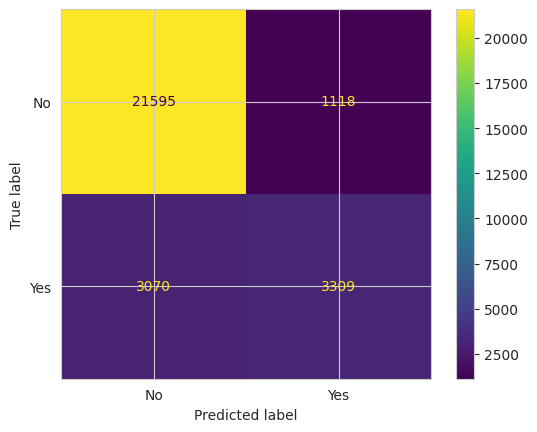

In [113]:
print("Accuracy:", accuracy_score(y_test_clear, y_pred_binary))
conf_matriz = confusion_matrix(y_test_clear, y_pred_binary)
visualizacion = ConfusionMatrixDisplay(confusion_matrix=conf_matriz, display_labels=["No","Yes"])
visualizacion.plot()
print("Matriz de confusión:\n", conf_matriz)
print(classification_report(y_test_clear, y_pred_binary))

In [115]:
from sklearn.utils.class_weight import compute_class_weight

In [116]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_encoded),
    y=y_encoded
)

class_weights = dict(enumerate(class_weights))
print("Pesos:", class_weights)

Pesos: {0: np.float64(0.6403246964774658), 1: np.float64(2.2815823320889668)}


In [120]:
model_keras.fit(X_train_clear, y_train_clear, epochs=10,
                batch_size=32, validation_split=0.2,
                class_weight=class_weights,
                verbose=1)

y_pred = model_keras.predict(X_test_clear)

y_pred = y_pred.round()

Epoch 1/10
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8053 - loss: 0.4165 - recall_18: 0.8107 - val_accuracy: 0.8112 - val_loss: 0.4057 - val_recall_18: 0.7888
Epoch 2/10
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8070 - loss: 0.4100 - recall_18: 0.8077 - val_accuracy: 0.8095 - val_loss: 0.4144 - val_recall_18: 0.7947
Epoch 3/10
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8055 - loss: 0.4125 - recall_18: 0.8122 - val_accuracy: 0.8121 - val_loss: 0.4057 - val_recall_18: 0.7882
Epoch 4/10
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8054 - loss: 0.4156 - recall_18: 0.8066 - val_accuracy: 0.8177 - val_loss: 0.3968 - val_recall_18: 0.7758
Epoch 5/10
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.8072 - loss: 0.4140 - recall_18: 0.8027 - val_accuracy: 0.8043 - val_loss: 0.4189 - val_recall_18: 0.8109
Epoch 6/10
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8054 - loss: 0.4066 - recall_18: 0.8108 - val_accuracy: 0.80

Accuracy: 0.8100508730922591
Matriz de confusión:
 [[18506  4207]
 [ 1319  5060]]
              precision    recall  f1-score   support

           0       0.93      0.81      0.87     22713
           1       0.55      0.79      0.65      6379

    accuracy                           0.81     29092
   macro avg       0.74      0.80      0.76     29092
weighted avg       0.85      0.81      0.82     29092



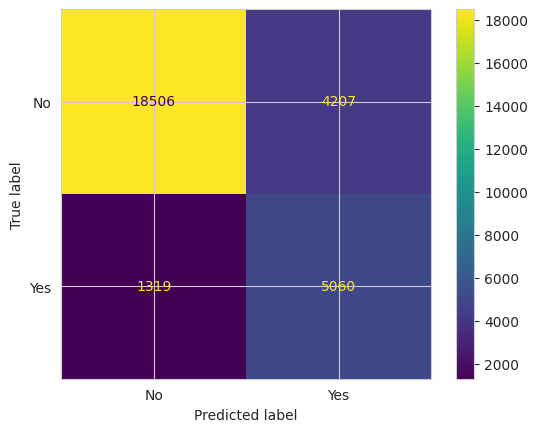

In [121]:
print("Accuracy:", accuracy_score(y_test_clear, y_pred))
conf_matriz = confusion_matrix(y_test_clear, y_pred)
visualizacion = ConfusionMatrixDisplay(confusion_matrix=conf_matriz, display_labels=["No","Yes"])
visualizacion.plot()
print("Matriz de confusión:\n", conf_matriz)
print(classification_report(y_test_clear, y_pred))

In [123]:
X_train_resampled, y_train_resampled = SMOTE(random_state=200).fit_resample(X_train_clear, y_train_clear)

fit_smote = model_keras.fit(X_train_resampled, y_train_resampled, epochs=10,
                batch_size=32, validation_split=0.2,
                class_weight=class_weights,
                verbose=1)
y_pred = model_keras.predict(X_test_clear)

y_pred = y_pred.round()

Epoch 1/10
4544/4544 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7779 - loss: 0.4577 - recall_18: 0.9083 - val_accuracy: 0.9408 - val_loss: 0.2037 - val_recall_18: 0.9408
Epoch 2/10
4544/4544 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.7725 - loss: 0.4526 - recall_18: 0.9175 - val_accuracy: 0.9429 - val_loss: 0.2119 - val_recall_18: 0.9429
Epoch 3/10
4544/4544 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.7705 - loss: 0.4507 - recall_18: 0.9190 - val_accuracy: 0.9454 - val_loss: 0.2135 - val_recall_18: 0.9454
Epoch 4/10
4544/4544 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.7741 - loss: 0.4459 - recall_18: 0.9201 - val_accuracy: 0.9509 - val_loss: 0.2062 - val_recall_18: 0.9509
Epoch 5/10
4544/4544 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.7701 - loss: 0.4507 - recall_18: 0.9202 - val_accuracy: 0.9456 - val_loss: 0.1970 - val_recall_18: 0.9456
Epoch 6/10
4544/4544 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.7741 - loss: 0.4488 - recall_18: 0.9193 - val_accuracy: 

Accuracy: 0.7318506805994776
Matriz de confusión:
 [[15576  7137]
 [  664  5715]]
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     22713
           1       0.44      0.90      0.59      6379

    accuracy                           0.73     29092
   macro avg       0.70      0.79      0.70     29092
weighted avg       0.85      0.73      0.75     29092



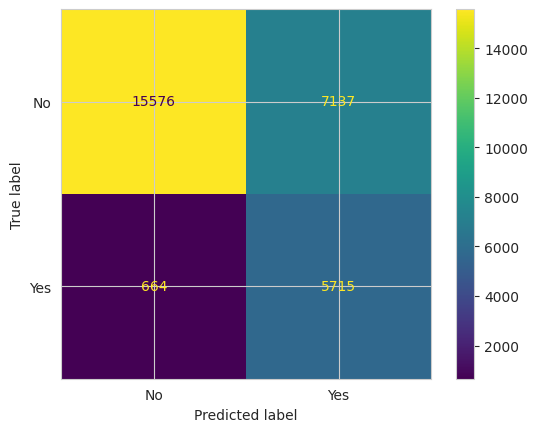

In [124]:
print("Accuracy:", accuracy_score(y_test_clear, y_pred))
conf_matriz = confusion_matrix(y_test_clear, y_pred)
visualizacion = ConfusionMatrixDisplay(confusion_matrix=conf_matriz, display_labels=["No","Yes"])
visualizacion.plot()
print("Matriz de confusión:\n", conf_matriz)
print(classification_report(y_test_clear, y_pred))